# Seleccion de Variables con Lasso


En el presente notebook se generan y se evalúan los siguientes modelos.

* Regresión lineal Lasso
* Regresión lineal
* Ridge
* Árbol de regresión
* KNN para regresión
* Regresión no paramétrica

El preprocesamiento principal se realiza mediante una seleccion de variables utilizando el metodo de regresion Lasso. 

In [1]:
library(pracma)
library(glmnet)
library("stats")
library("partykit")
library(ggplot2)
source("Utils.R")

Loading required package: Matrix

Attaching package: ‘Matrix’

The following objects are masked from ‘package:pracma’:

    expm, lu, tril, triu

Loading required package: foreach
Loaded glmnet 2.0-16

Loading required package: grid
Loading required package: libcoin
Loading required package: mvtnorm
Registered S3 methods overwritten by 'ggplot2':
  method         from 
  [.quosures     rlang
  c.quosures     rlang
  print.quosures rlang


In [2]:
library(reticulate)
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

StScaler <- import("sklearn.preprocessing", convert = FALSE)$StandardScaler
MMScaler <- import("sklearn.preprocessing", convert = FALSE)$MinMaxScaler

### Division de los datos

In [3]:
setSeed()

vasijas_X <- obtener_X()
vasijas_Y <- obtener_Y()

df <- vasijas_X
df$Y <- vasijas_Y


hold_out_ind <- obtener_holdout_ind(vasijas_X)

HOLDOUT_X <- vasijas_X[hold_out_ind, ]
HOLDOUT_Y <- vasijas_Y[hold_out_ind]
HOLDOUT_DF <- df[hold_out_ind, ]

TRAIN_Y <- vasijas_Y[-hold_out_ind]
TRAIN_X <- vasijas_X[-hold_out_ind, ]
TRAIN_DF <- df[-hold_out_ind, ]

# Seleccion de Variables con Lasso

### Modelo sin tuneo de parametros y sin escalar 

In [4]:
model <- glmnet(as.matrix(TRAIN_X), TRAIN_Y, alpha=1)

In [5]:
Y_pred = predict(model, as.matrix(TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.694377895643682  usando el modelo numero:  100"


In [6]:
best_lambda = model$lambda[100]
print(paste("El lambda utilizado es: ", best_lambda))

[1] "El lambda utilizado es:  0.0372287988245699"


In [7]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, alpha=1, lambda = best_lambda)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.26012561111025"


### Busqueda del mejor lambda

In [8]:
setSeed()
escalador <- MMScaler()
X_train_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
cv_result <- cv.glmnet(X_train_scaled, TRAIN_Y, alpha = 1, lambda = logspace(-4, 0, 100), nfolds = 5)

In [9]:
lambda_optimo <- cv_result$lambda.1se
lambda_min <- cv_result$lambda.min
lambda_optimo

[1] 0.02009233

In [10]:
a <- data.frame(
    Lambda <-  cv_result$lambda,
    SD <- cv_result$cvsd,
    Y <- cv_result$cvm,
    color <- sapply(cv_result$lambda, function(x) 
                (ifelse(x==lambda_optimo, "LambdaOp", ifelse(x==lambda_min, "LambdaMin", "Nada"))))
)
colnames(a) <- c("Lambda", "SD", "ECMCV", "Color")

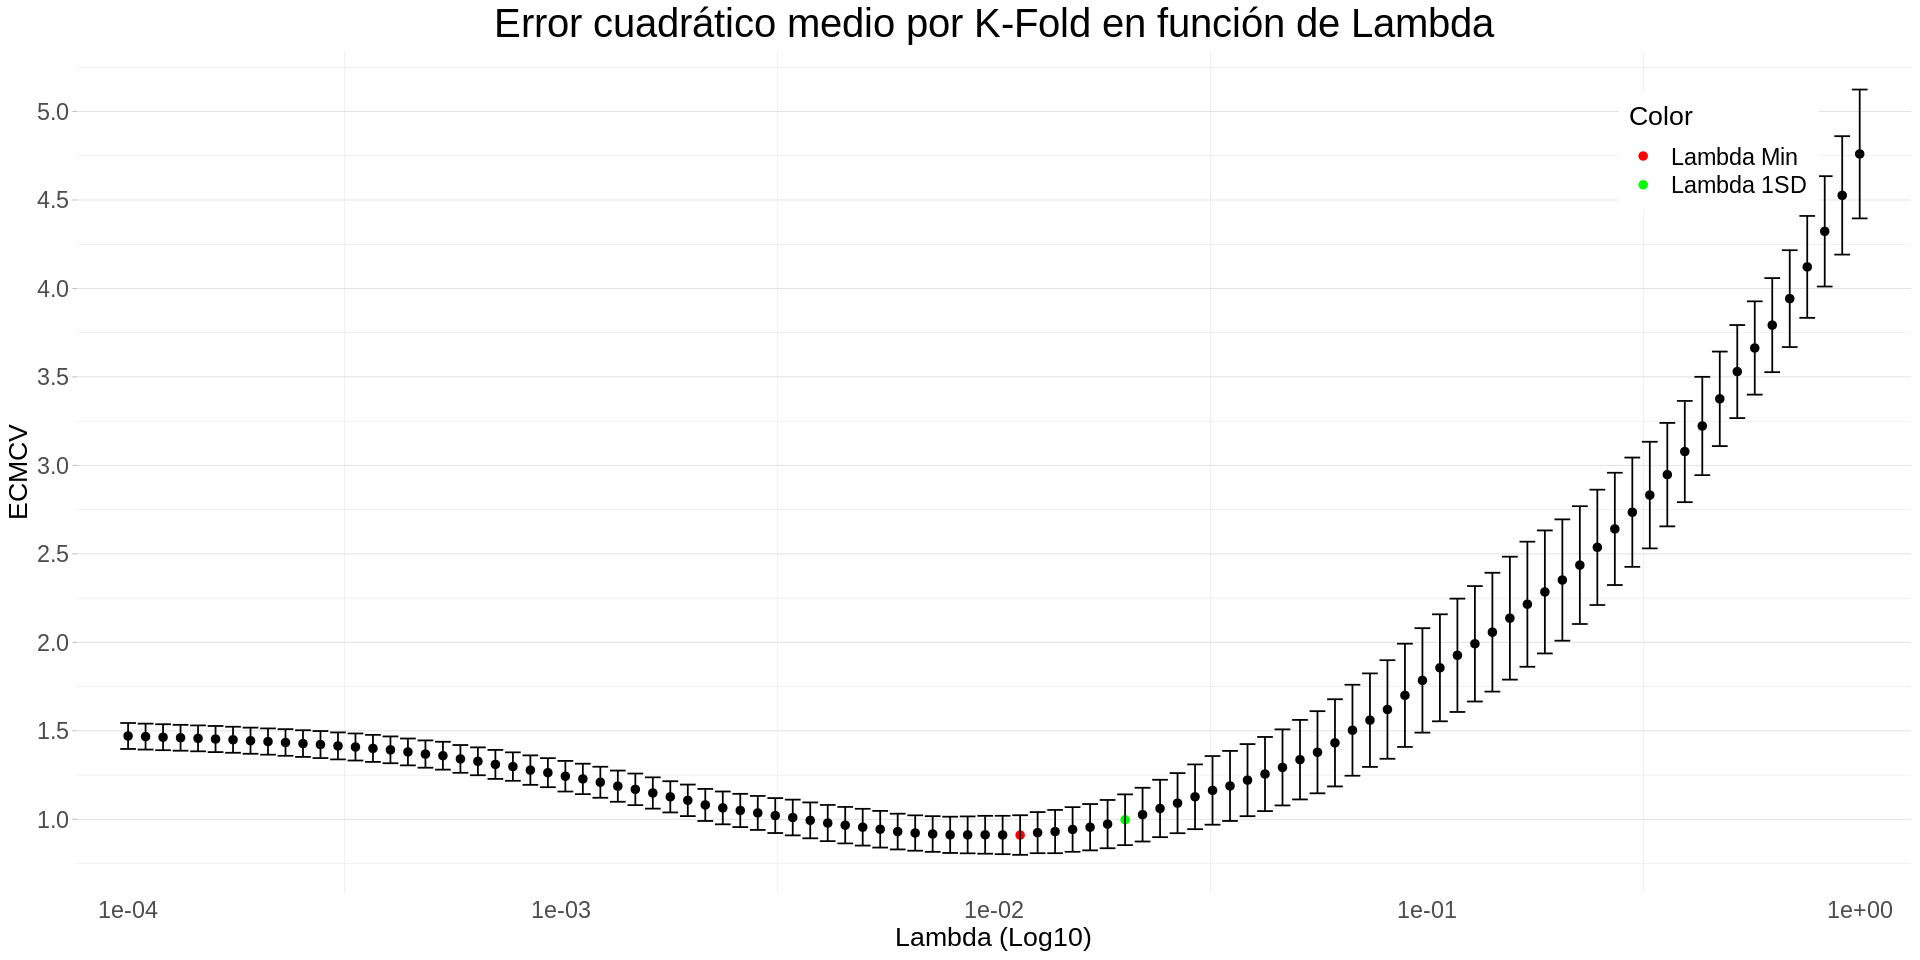

In [11]:
options(repr.plot.width=16, repr.plot.height=8)

ggplot(a, aes(x = Lambda, y = ECMCV)) + 
  ggtitle("Error cuadrático medio por K-Fold en función de Lambda") +
  geom_point(aes(x = Lambda, y = ECMCV,color = Color), size = 2) + 
  geom_errorbar(aes(ymin = ECMCV - SD, ymax = ECMCV + SD)) +
  theme_light() +
  scale_colour_manual(values = c("LambdaMin" = "red", "LambdaOp" = "Green", "Nada" = "Black"),
                      labels = c("Lambda Min", "Lambda 1SD"), breaks = c("LambdaMin", "LambdaOp")) + 
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank(),
        legend.position = c(.95, .95),
        legend.justification = c("right", "top"),
        legend.box.just = "right",
        legend.margin = margin(6, 6, 6, 6),
        legend.title = element_text(size=16),
        legend.text = element_text(size=14)) +
  scale_x_continuous(trans = 'log10',  expand = c(0,0.1), breaks = logspace(-6, 0, 7)) +
  scale_y_continuous(breaks = seq(0, 6, by=0.5)) +
  xlab("Lambda (Log10)") + ylab("ECMCV")

### Calculo del error por LOOCV

In [12]:
n = nrow(TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- TRAIN_X
err = 0
escalador = MMScaler()
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=lambda_min, alpha=1)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.824195492875652"


In [13]:
X_scaled <- as.matrix(escalador$fit_transform(TRAIN_X))
X_holdout_scaled_modelo_1 = as.matrix(escalador$transform(HOLDOUT_X))
modelo1 <- glmnet(X_scaled, TRAIN_Y, alpha=1, lambda=lambda_min)

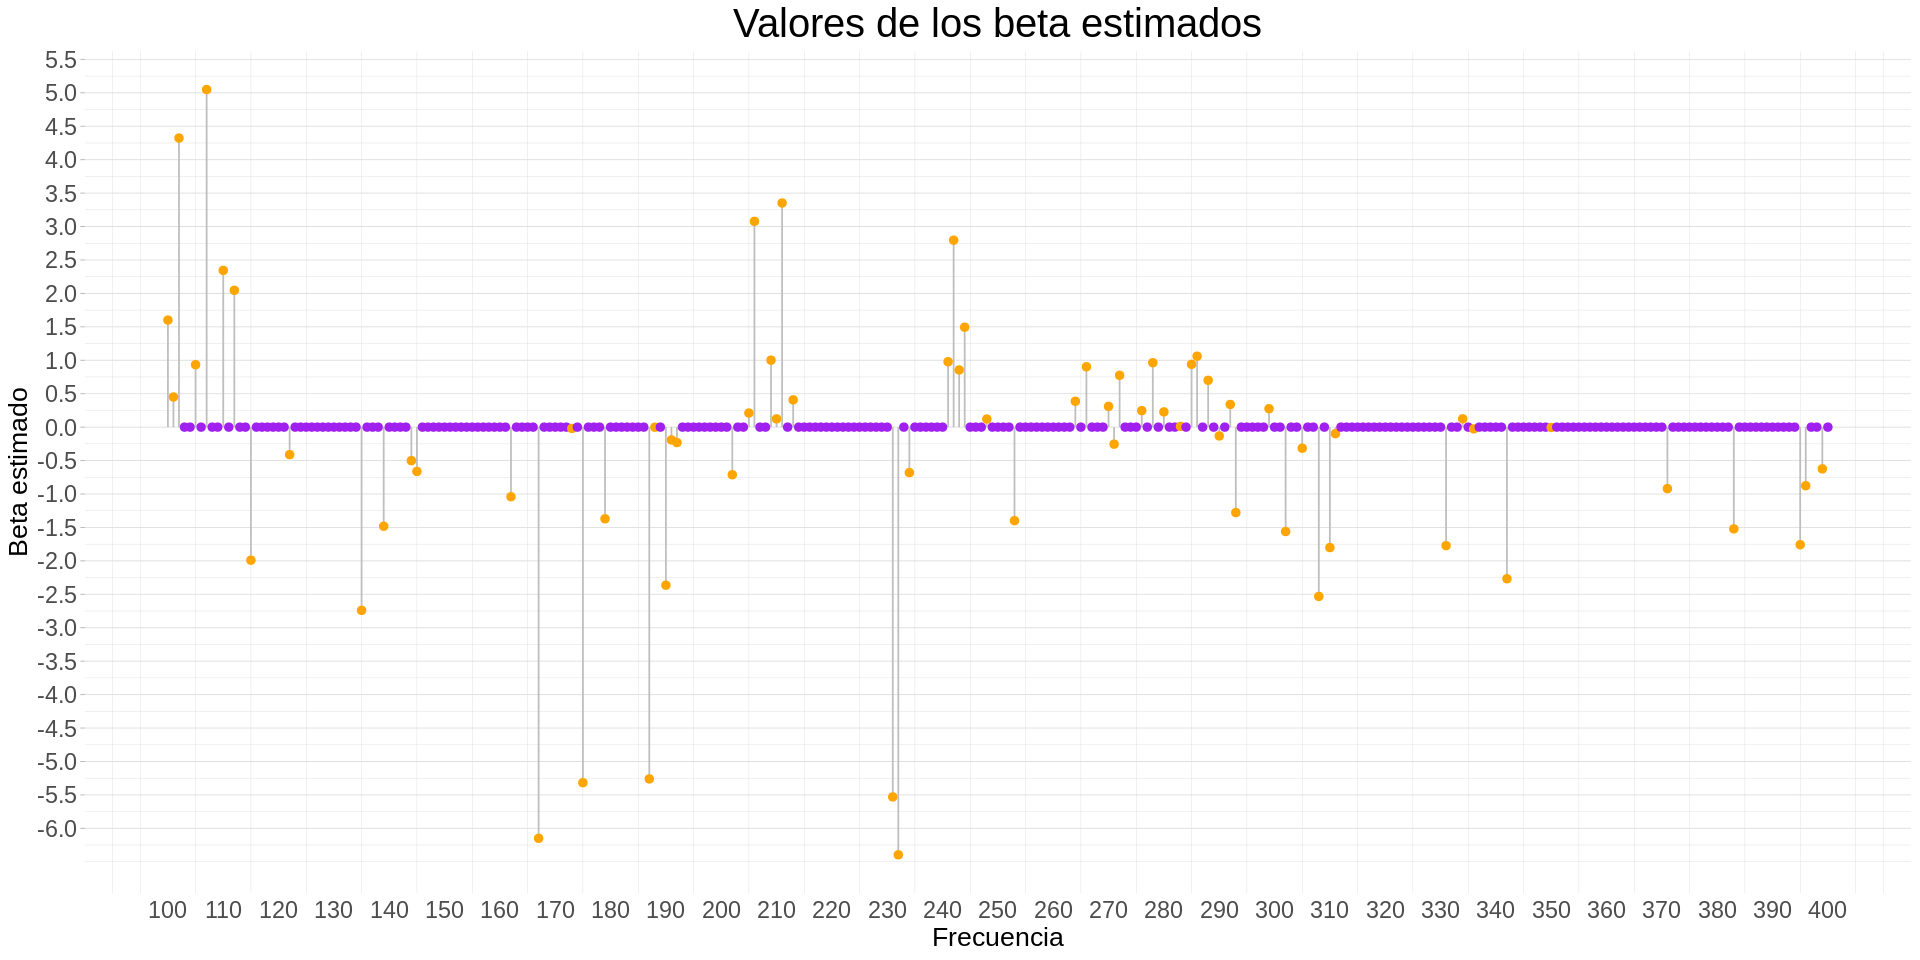

In [14]:
x_plot = as.integer(sub('.', '', colnames(TRAIN_X))) + 99

data_plot <- data.frame(
  x=x_plot,
  y=modelo1$beta[,1]
)


# Plot

options(repr.plot.width=16, repr.plot.height=8)

colores = sapply(modelo1$beta[,1], function(x) (ifelse(x!=0, "orange",  "purple")))
ggplot(data_plot, aes(x=x, y=y)) +
  ggtitle("Valores de los beta estimados") +
  geom_segment( aes(x=x, xend=x, y=0, yend=y), color="grey") +
  geom_point(color=colores, size=2) +
  theme_light() +
  theme(plot.title = element_text(hjust = 0.5, size = 24),
        axis.text=element_text(size=14),
        axis.title=element_text(size=16),
        panel.grid.major.x = element_blank(),
        panel.border = element_blank(),
        axis.ticks.x = element_blank()) +
  scale_x_continuous(breaks = seq(100, 400, by=10)) +
  scale_y_continuous(breaks = seq(-6, 6, by=0.5)) +
  xlab("Frecuencia") + ylab("Beta estimado")

In [15]:
variables_to_filter = modelo1$beta[,1] != 0
print(paste("El mejor modelo de Lasso encontrado elimino ", sum(modelo1$beta[,1] == 0), " variables"))
print(paste("El mejor modelo de Lasso encontrado se quedo con ", sum(modelo1$beta[,1] != 0), " variables"))

[1] "El mejor modelo de Lasso encontrado elimino  231  variables"
[1] "El mejor modelo de Lasso encontrado se quedo con  70  variables"


In [16]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.916624412785734"


In [17]:
SELECTED_TRAIN_X <- TRAIN_X[, variables_to_filter]
SELECTED_TRAIN_DF <- SELECTED_TRAIN_X
SELECTED_TRAIN_DF$Y <- TRAIN_Y

SELECTED_HOLDOUT_X <- HOLDOUT_X[, variables_to_filter]
SELECTED_HOLDOUT_DF <- SELECTED_HOLDOUT_X
SELECTED_HOLDOUT_DF$Y <- HOLDOUT_Y

# Modelo 2: Regresion Lineal

In [18]:
# No escalamos los datos porque no hay regularizacion.
modelo2 <- lm(Y~., data = SELECTED_TRAIN_DF)

In [19]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    df_train = X[-i,]
    df_train$Y = TRAIN_Y[-i]
    
    X_test = X[i,]
    Y_test = TRAIN_Y[i]

    model <- lm(Y~.,  data = df_train)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.473876368294813"


In [20]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.95206268316793"


# Modelo 3: Regresion Lineal Regularizada

### Sólo iterando lambda y sin escalar

In [21]:
model <- glmnet(as.matrix(SELECTED_TRAIN_X), TRAIN_Y)

In [22]:
Y_pred = predict(model, as.matrix(SELECTED_TRAIN_X))
error_min <- sum((TRAIN_Y - Y_pred[, 1])^2) / nrow(SELECTED_TRAIN_X)
best_model <- 1
for (i in 2:ncol(Y_pred)) {
    curr_error <- sum((TRAIN_Y - Y_pred[, i])^2) / nrow(SELECTED_TRAIN_X)
    if (curr_error < error_min) {
        error_min <- curr_error 
        best_model <- i
    }
}
print(paste("El error cuadratico medio de train es: ", error_min, " usando el modelo numero: ", best_model))

[1] "El error cuadratico medio de train es:  0.152503445936276  usando el modelo numero:  82"


In [23]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){

    X_train_scaled = X[-i,]
    Y_train = TRAIN_Y[-i]

    X_test_scaled = X[i,]
    Y_test = TRAIN_Y[i]

    model <- glmnet(as.matrix(X_train_scaled), Y_train, lambda=0.0372, alpha=1)
    Y_pred = predict(model, as.matrix(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.15461169329716"


### Busqueda de los parametros de la prediccion

In [24]:
setSeed()
n = nrow(SELECTED_TRAIN_X)
k = 5
resultados <- data.frame(
  Alpha   =double(),
  Lambda  =double(),
  Escalador = integer(),
  Error   =double()
)

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

alphas <- seq(0, 1, 0.05)
lambdas <- logspace(-10, 3, 50)
escaladores <- c(StScaler(), MMScaler())


for (alpha in alphas) {
    for (lambda in lambdas) {
        for(s in 1:length(escaladores)){
            escalador = escaladores[[s]] 
            err = 0
            for (i in indices) {
                X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                Y_train = TRAIN_Y[-i]

                X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                Y_test = TRAIN_Y[i]

                model <- glmnet(X_train_scaled, Y_train, lambda=lambda, alpha=alpha)
                Y_pred = predict(model, X_test_scaled)
                err = err + sum((Y_test - Y_pred)^2)
            }
            resultados = rbind(resultados, list(alpha, lambda, s, err/n))
        }
    }
    message(progreso(alpha, alphas))
}

colnames(resultados)  <- c("alpha", "lambda", "Escalador", "Error")

El progreso es del 4.8 %
El progreso es del 9.5 %
El progreso es del 14.3 %
El progreso es del 19 %
El progreso es del 23.8 %
El progreso es del 28.6 %
El progreso es del 33.3 %
El progreso es del 38.1 %
El progreso es del 42.9 %
El progreso es del 47.6 %
El progreso es del 52.4 %
El progreso es del 57.1 %
El progreso es del 61.9 %
El progreso es del 66.7 %
El progreso es del 71.4 %
El progreso es del 76.2 %
El progreso es del 81 %
El progreso es del 85.7 %
El progreso es del 90.5 %
El progreso es del 95.2 %
El progreso es del 100 %


Los mejores parámetros obtenidos fueron entonces:

In [25]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,alpha,lambda,Escalador,Error
65,0,0.03088844,1,0.3894997


### Calculo del error por LOOCV

In [26]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
escalador = escaladores[[mejores_parametros$Escalador]]
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- glmnet(X_train_scaled, Y_train, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)
    Y_pred = predict(model, X_test_scaled)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.392401205808532"


In [27]:
X_train_scaled <- as.matrix(escalador$fit_transform(X))
X_holdout_scaled_modelo3 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
modelo3 <- glmnet(X_train_scaled, TRAIN_Y, lambda=mejores_parametros$lambda, alpha=mejores_parametros$alpha)

p = sum(modelo3$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.960304707753591"


In [28]:
p

[1] 70

No elimino ninguno

# Modelo 4: árbol de regresión

### Busqueda de los parametros de la prediccion

In [29]:
library(rpart)
library(rpart.plot)

In [30]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
  Minsplit =double(),
  Maxdepth =double(),
  CP       =double(),
  Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X

minsplits <- c(2, 5, 10, 20, 30, 50)

for (minsplit in minsplits) {
    for (maxdepth in c(4, 5, 6, 7, 8)) {
        for (cp in c(0.0005, 0.001, 0.005, 0.01, 0.015, 0.025)) {
            parametros = rpart.control(minsplit=minsplit, maxdepth=maxdepth, cp=cp)
            err = 0
            for(i in indices) {
                DF_train = X[-i,]
                DF_train$Y = TRAIN_Y[-i]

                DF_test = X[i,]
                DF_test$Y = TRAIN_Y[i]
                
                model <- rpart(Y ~ ., data = DF_train, control=parametros, xval=1)
                Y_pred = predict(model, DF_test)
                err = err + sum((DF_test$Y - Y_pred)^2)
            }
            resultados = rbind(resultados, list(minsplit, maxdepth, cp, err/n))
        }
    }
    message(progreso(minsplit, minsplits))
}

colnames(resultados)  <- c("Minsplit", "Maxdepth", "CP", "Error")

El progreso es del 16.7 %
El progreso es del 33.3 %
El progreso es del 50 %
El progreso es del 66.7 %
El progreso es del 83.3 %
El progreso es del 100 %


In [31]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

Minsplit,Maxdepth,CP,Error
2,4,5e-04,1.655705


### Calculo del error

In [32]:
parametros <- rpart.control(minsplit=mejores_parametros$Minsplit, maxdepth=mejores_parametros$Maxdepth, cp=mejores_parametros$CP)

modelo4 <- rpart(Y ~ ., data = SELECTED_TRAIN_DF, control=parametros)

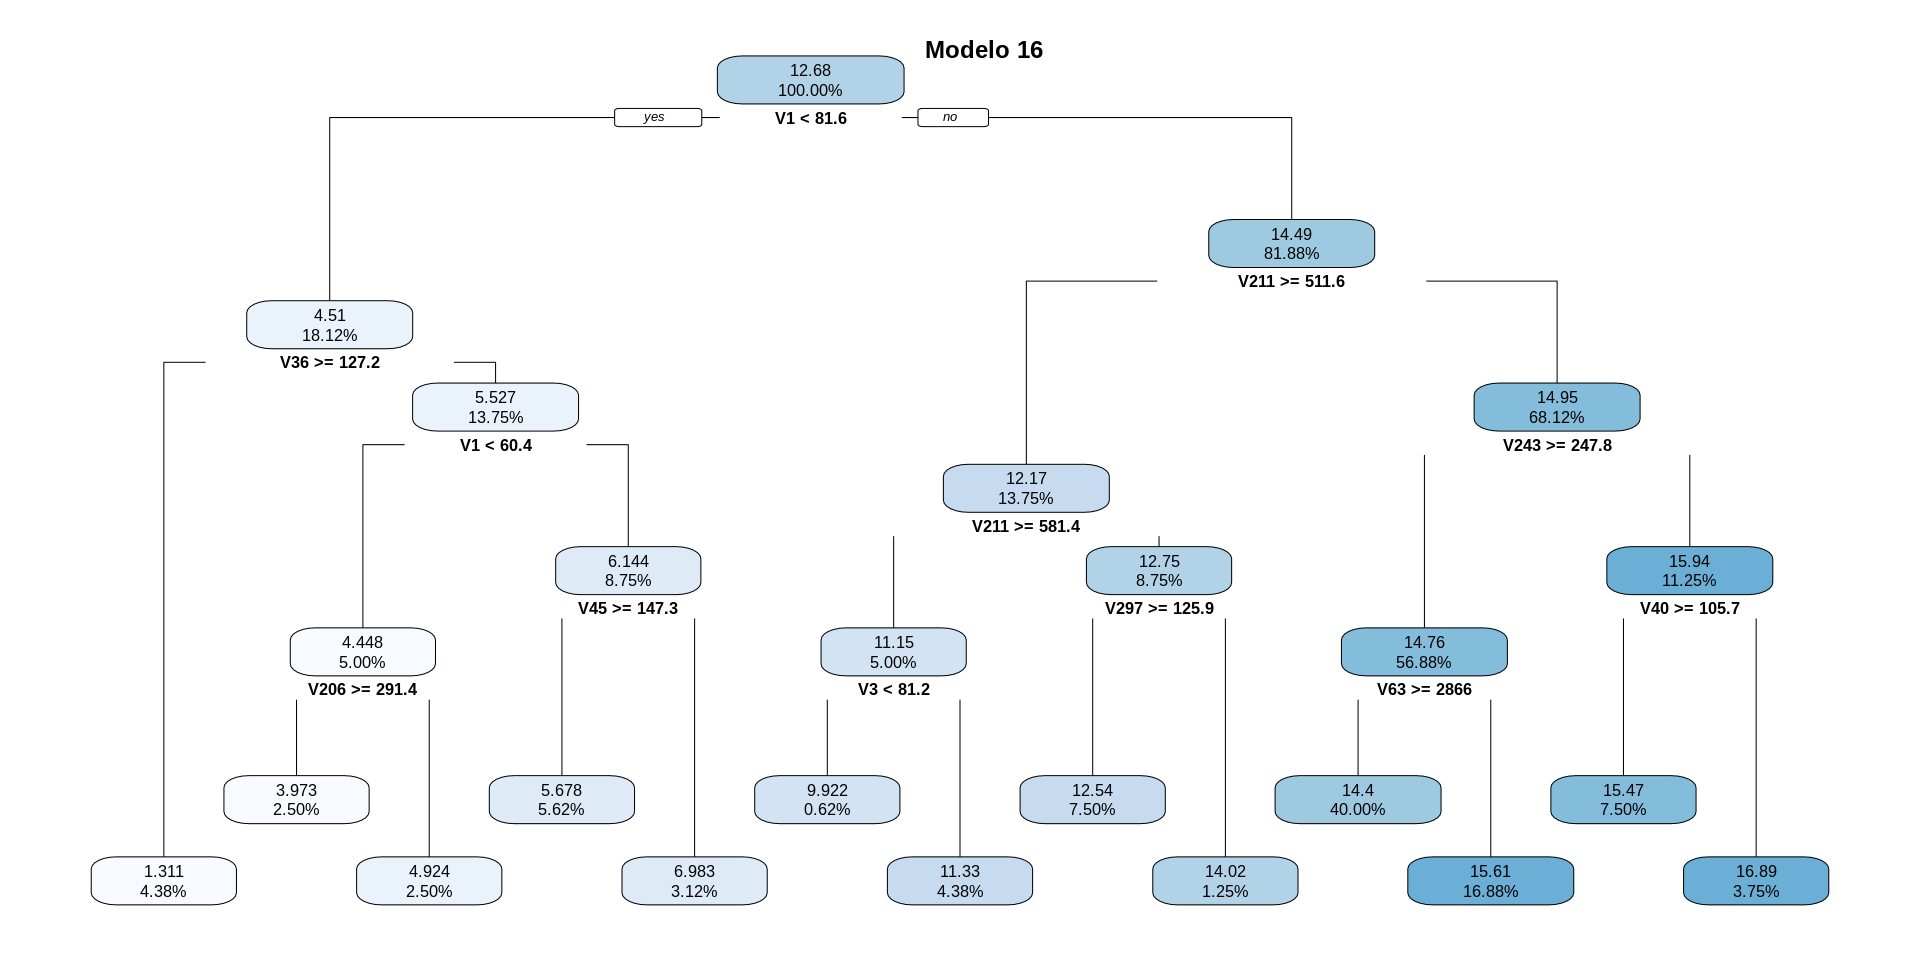

In [33]:
rpart.plot(modelo4, digits=4)
title("Modelo 16")

In [34]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
err = 0
for(i in indices){
    train_df <- X[-i,]
    train_df$Y <- TRAIN_Y[-i]
    X_test <- X[i,]
    Y_test = TRAIN_Y[i]

    model <- rpart(Y ~ ., data = train_df, control=parametros)
    Y_pred = predict(model, X_test)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  1.39659211173106"


In [35]:
p <- length(unique(summary(modelo4)$frame$var))-1

Call:
rpart(formula = Y ~ ., data = SELECTED_TRAIN_DF, control = parametros)
  n= 160 

             CP nsplit  rel error     xerror       xstd
1  0.8457815140      0 1.00000000 1.01476076 0.13685629
2  0.0506953513      1 0.15421849 0.17587685 0.02261820
3  0.0337894459      2 0.10352313 0.13898075 0.02075144
4  0.0087776313      3 0.06973369 0.09662946 0.01554029
5  0.0052399391      5 0.05217843 0.09941662 0.01601662
6  0.0046736994      6 0.04693849 0.09297596 0.01369015
7  0.0028817535      7 0.04226479 0.09278882 0.01394181
8  0.0019596237      8 0.03938303 0.09228549 0.01392576
9  0.0013444242      9 0.03742341 0.08895045 0.01193384
10 0.0006466486     10 0.03607899 0.08778398 0.01185219
11 0.0006192831     11 0.03543234 0.08824038 0.01176228
12 0.0005000000     12 0.03481305 0.08824038 0.01176228

Variable importance
  V1   V3   V2 V243   V6 V237 V211 V212  V23 V209 V232  V40  V36  V16  V45  V13 
  16   16   15   14   14   14    1    1    1    1    1    1    1    1    1    1 
V

In [36]:
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
print(paste("R2 adj =  ", hatY))

[1] "R2 adj =   0.915232474512968"


# Modelo 5: KNN para regresión

In [37]:
library(reticulate)

In [38]:
np <- import("numpy", convert = FALSE)
pd <- import("pandas", convert = FALSE)

In [39]:
knnr <- import("sklearn.neighbors", convert = FALSE)$KNeighborsRegressor

### Sin tuneo de parametros

In [40]:
model <- knnr()$fit(SELECTED_TRAIN_X, TRAIN_Y)

In [41]:
Y_pred = as.double(model$predict(SELECTED_TRAIN_X))
error <- sum((TRAIN_Y - Y_pred)^2) / nrow(SELECTED_TRAIN_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.698218057749999"


### Busqueda de los parametros de la prediccion

In [42]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

resultados <- data.frame(
    K        =integer(),
    Weights  =integer(),
    p        =integer(),
    S        =integer(),
    Error    =double()
)

indices = obtener_indices_kfold(n, k)

X <- SELECTED_TRAIN_X
escaladores <- c(StScaler(), MMScaler())
for(K in 1:10){
    for(w in c(1, 2)){
        wei = ifelse(w==1, "uniform", "distance")
        for(p in c(1, 2)){
            for(s in 1:length(escaladores)){
                escalador = escaladores[[s]]
                err = 0
                for(i in indices){
                    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
                    Y_train = TRAIN_Y[-i]

                    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
                    Y_test = TRAIN_Y[i]
                    
                    model <- knnr(n_neighbors=K, p=p, weights=wei)$fit(X_train_scaled, Y_train)
                    Y_pred = as.double(model$predict(X_test_scaled))
                    err = err + sum((Y_test - Y_pred)^2)
                }
                resultados = rbind(resultados, list(K, w, p, s, err/n))
            }
        }
    }
    message(progreso(K, 1:10))
}
colnames(resultados)  <- c("K", "Weights", "Distance", "Escalador", "Error")

El progreso es del 10 %
El progreso es del 20 %
El progreso es del 30 %
El progreso es del 40 %
El progreso es del 50 %
El progreso es del 60 %
El progreso es del 70 %
El progreso es del 80 %
El progreso es del 90 %
El progreso es del 100 %


In [43]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,K,Weights,Distance,Escalador,Error
30,4,2,1,2,0.7927517


### Calculo del error

In [44]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = escaladores[[mejores_parametros$Escalador]]
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    model <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, Y_train)
    Y_pred = as.double(model$predict(X_test_scaled))
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.800604992110983"


In [62]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9190108

In [46]:
escalador = escaladores[[mejores_parametros$Escalador]]
X_train_scaled <- as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo5 <- as.matrix(escalador$transform(SELECTED_HOLDOUT_X))
wei <- ifelse(mejores_parametros$Weights==1, "uniform", "distance")

modelo5 <- knnr(n_neighbors=mejores_parametros$K, p=mejores_parametros$Distance, weights=wei)$fit(X_train_scaled, TRAIN_Y)

# Modelo 6: regresión no paramétrica

$$\hat{m}_{h}(x) = \frac{\sum^{n}_{i=1} K(\frac{x-x_i}{h}) y_i}{\sum^{n}_{i=1}K(\frac{x-x_i}{h})} = \sum^{n}_{i=1} w_i(x) y_i$$

In [47]:
D <- function(x, y) (sum((abs(x-y))))
calc <- function(X, Y, h, K, x0){
    wis <- apply(X, 1, function(xi) (K(D(xi, x0)/h)))
    return(sum(wis*Y)/sum(wis))
}
npr <- function(x, X, Y, h, K){
    return(apply(x, 1, function(x0) (calc(X, Y, h, K, x0))))
}

In [48]:
setSeed()

n = nrow(SELECTED_TRAIN_X)
k = 10

indices = obtener_indices_kfold(n, k)
X <- SELECTED_TRAIN_X

resultados <- data.frame(
    h       =double(),
    K       =integer(),
    Error   =double()
)
escalador = StScaler()

hs = seq(0.1, 15, l=30)
Ks = list((function(x) (0.5 * (abs(x)<1))),
          (function(x) (dnorm(x))),
          (function(x) (0.75*(1-x^2)*(abs(x)<1))),
          (function(x) ((15/16)*((1-x^2)^2)*(abs(x)<1)))
       )

for(h in hs){
    for(Knumber in 1:length(Ks)){
        K = Ks[[Knumber]]
        err = 0
        for(i in indices){
            X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
            Y_train = TRAIN_Y[-i]

            X_test_scaled = as.matrix(escalador$transform(X[i, ]))
            Y_test = TRAIN_Y[i]
            
            Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, h, K)
            err = err + sum((Y_test - Y_pred)^2)
        }
        resultados = rbind(resultados, list(h, Knumber, err/n))
    }
    message(progreso(h, hs))
}
colnames(resultados)  <- c("h", "K", "Error")

El progreso es del 3.3 %
El progreso es del 6.7 %
El progreso es del 10 %
El progreso es del 13.3 %
El progreso es del 16.7 %
El progreso es del 20 %
El progreso es del 23.3 %
El progreso es del 26.7 %
El progreso es del 30 %
El progreso es del 33.3 %
El progreso es del 36.7 %
El progreso es del 40 %
El progreso es del 43.3 %
El progreso es del 46.7 %
El progreso es del 50 %
El progreso es del 53.3 %
El progreso es del 56.7 %
El progreso es del 60 %
El progreso es del 63.3 %
El progreso es del 66.7 %
El progreso es del 70 %
El progreso es del 73.3 %
El progreso es del 76.7 %
El progreso es del 80 %
El progreso es del 83.3 %
El progreso es del 86.7 %
El progreso es del 90 %
El progreso es del 93.3 %
El progreso es del 96.7 %
El progreso es del 100 %


In [49]:
mejores_parametros <- resultados[which.min(resultados$Error),]
mejores_parametros

,h,K,Error
54,6.77931,2,0.8855939


In [50]:
n = nrow(SELECTED_TRAIN_X)
indices = obtener_indices_kfold(n, n)
X <- SELECTED_TRAIN_X
escalador = StScaler()
K = Ks[[mejores_parametros$K]]
err = 0
for(i in indices){
    X_train_scaled = as.matrix(escalador$fit_transform(X[-i, ]))
    Y_train = TRAIN_Y[-i]

    X_test_scaled = as.matrix(escalador$transform(X[i, ]))
    Y_test = TRAIN_Y[i]

    Y_pred = npr(X_test_scaled, X_train_scaled, Y_train, mejores_parametros$h, K)
    err = err + sum((Y_test - Y_pred)^2)
}
err = err/n
print(paste("El error cuadratico medio con LOOCV de train es: ", err))

[1] "El error cuadratico medio con LOOCV de train es:  0.830985347103426"


In [63]:
p = sum(modelo1$beta[,1] != 0)
num = n*err*(n-1)
den = sum((TRAIN_Y-mean(TRAIN_Y))^2)*(n-p)
hatY = 1-num/den
hatY

[1] 0.9159376

In [52]:
escalador = StScaler()
X_train_scaled_modelo6 = as.matrix(escalador$fit_transform(SELECTED_TRAIN_X))
X_holdout_scaled_modelo6 = as.matrix(escalador$transform(SELECTED_HOLDOUT_X))

# Errores de HOLDOUT

## Modelo 1: Lasso

In [53]:
Y_pred = predict(modelo1, X_holdout_scaled_modelo_1)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  1.03414951173758"


## Modelo 2: Regresion Lineal

In [54]:
Y_pred = predict(modelo2, SELECTED_HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  1.9712380641162"


## Modelo 3: Ridge

In [55]:
Y_pred = predict(modelo3, X_holdout_scaled_modelo3)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  1.41795905191849"


## Modelo 4: Arbol de Regresion

In [56]:
Y_pred = predict(modelo4, SELECTED_HOLDOUT_X)
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de holdout es: ", error))

[1] "El error cuadratico medio de holdout es:  0.816813930243931"


## Modelo 5: KNN

In [57]:
Y_pred = as.double(modelo5$predict(X_holdout_scaled_modelo5))
error <- sum((HOLDOUT_Y - Y_pred)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.975301375710626"


## Modelo 6: Regresion No Parametrica

In [58]:
K = Ks[[mejores_parametros$K]]
Y_pred_modelo6 <- npr(X_holdout_scaled_modelo6, X_train_scaled_modelo6, TRAIN_Y, mejores_parametros$h, K)
error <- sum((HOLDOUT_Y - Y_pred_modelo6)^2) / nrow(SELECTED_HOLDOUT_X)
print(paste("El error cuadratico medio de train es: ", error))

[1] "El error cuadratico medio de train es:  0.844375881276184"
